# Hyperparameter Experiments

Three systematic sweeps, all logged to the MLflow **makemore** experiment.

| Sweep | What varies | Fixed |
|-------|------------|-------|
| **Context length** | `block_size` = 3, 6, 8, 12, 16 | embd=10, hidden=200, batch=32 |
| **Batch size** | `batch_size` = 16, 32, 64, 128 | block=3, embd=10, hidden=200 |
| **Architecture** | `(n_embd, n_hidden)` tiny/small/medium/large | block=3, batch=32 |

All runs use **50 000 training steps**, SGD with step-decay LR (0.1 → 0.01), and a single hidden-layer MLP + manual BatchNorm (Part 3 Part-A architecture).

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random, os, mlflow

%matplotlib inline

# Ensure cwd is project root (names.txt lives there)
if not os.path.exists('names.txt') and os.path.exists('../names.txt'):
    os.chdir('..')

os.makedirs('checkpoints', exist_ok=True)
mlflow.set_experiment('makemore')

words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi  = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

def build_dataset(words_list, block_size):
    X, Y = [], []
    for w in words_list:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

print(f'Dataset: {len(words):,} words   vocab_size={vocab_size}')


Dataset: 32,033 words   vocab_size=27


In [2]:
def train_model(config, Xtr, Ytr, Xdev, Ydev, run_name, experiment_tag):
    """Single hidden-layer MLP + manual BatchNorm. Logs every run to MLflow."""
    block_size = config['block_size']
    n_embd     = config['n_embd']
    n_hidden   = config['n_hidden']
    max_steps  = config['max_steps']
    batch_size = config['batch_size']

    g = torch.Generator().manual_seed(2147483647)

    C      = torch.randn((vocab_size, n_embd), generator=g)
    W1     = torch.randn((n_embd * block_size, n_hidden), generator=g) \
             * (5/3) / (n_embd * block_size) ** 0.5
    W2     = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
    b2     = torch.zeros(vocab_size)
    bngain = torch.ones((1, n_hidden))
    bnbias = torch.zeros((1, n_hidden))

    parameters = [C, W1, W2, b2, bngain, bnbias]
    for p in parameters:
        p.requires_grad = True

    bnmean_running = torch.zeros((1, n_hidden))
    bnstd_running  = torch.ones((1, n_hidden))

    with mlflow.start_run(run_name=run_name, tags={'experiment': experiment_tag}):
        mlflow.log_params({**config, 'experiment': experiment_tag})

        for i in range(max_steps):
            ix     = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
            Xb, Yb = Xtr[ix], Ytr[ix]

            emb     = C[Xb]
            embcat  = emb.view(emb.shape[0], -1)
            hpreact = embcat @ W1

            bnmeani = hpreact.mean(0, keepdim=True)
            bnstdi  = hpreact.std(0, keepdim=True)
            hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
            with torch.no_grad():
                bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
                bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi

            h      = torch.tanh(hpreact)
            logits = h @ W2 + b2
            loss   = F.cross_entropy(logits, Yb)

            for p in parameters:
                p.grad = None
            loss.backward()

            lr = 0.1 if i < max_steps // 2 else 0.01
            for p in parameters:
                p.data += -lr * p.grad

            if i % 10_000 == 0:
                mlflow.log_metric('loss_step', loss.item(), step=i)

        # Calibrate BN over full training set for correct inference
        with torch.no_grad():
            emb        = C[Xtr]
            embcat     = emb.view(emb.shape[0], -1)
            hpreact    = embcat @ W1
            bnmean_cal = hpreact.mean(0, keepdim=True)
            bnstd_cal  = hpreact.std(0, keepdim=True)

        @torch.no_grad()
        def get_loss(X, Y):
            emb    = C[X]
            embcat = emb.view(emb.shape[0], -1)
            h_pre  = embcat @ W1
            h_pre  = bngain * (h_pre - bnmean_cal) / bnstd_cal + bnbias
            h      = torch.tanh(h_pre)
            logits = h @ W2 + b2
            return F.cross_entropy(logits, Y).item()

        train_loss = get_loss(Xtr, Ytr)
        val_loss   = get_loss(Xdev, Ydev)
        mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss})
        print(f'  {run_name:42s}  train={train_loss:.4f}  val={val_loss:.4f}')

    return train_loss, val_loss

MAX_STEPS = 50_000
print('Training function ready.')


Training function ready.


## Experiment 1 — Context Length

`block_size` controls how many prior characters the model sees when predicting the next one. Longer context should reduce val loss up to a point; beyond that, gains shrink and training becomes harder because the input layer grows proportionally.

In [3]:
ctx_results = []
print('=== Experiment 1: Context Length ===')
for block_size in [3, 6, 8, 12, 16]:
    Xtr_b,  Ytr_b  = build_dataset(words[:n1],   block_size)
    Xdev_b, Ydev_b = build_dataset(words[n1:n2], block_size)
    cfg = {'block_size': block_size, 'n_embd': 10, 'n_hidden': 200,
           'max_steps': MAX_STEPS, 'batch_size': 32}
    tl, vl = train_model(cfg, Xtr_b, Ytr_b, Xdev_b, Ydev_b,
                         f'ctx-block{block_size}', 'context_length')
    ctx_results.append({'block_size': block_size, 'train': tl, 'val': vl})


=== Experiment 1: Context Length ===


  ctx-block3                                  train=2.1298  val=2.1505


  ctx-block6                                  train=2.0526  val=2.0898


  ctx-block8                                  train=2.0435  val=2.0905


  ctx-block12                                 train=2.0280  val=2.0758


  ctx-block16                                 train=2.0216  val=2.0731


## Experiment 2 — Batch Size

Smaller batches add noise to the gradient estimate, which can help escape sharp minima but also slow convergence. Larger batches are more stable but require more memory and may converge to flatter, more generalizable minima.

In [4]:
Xtr3,  Ytr3  = build_dataset(words[:n1],   3)
Xdev3, Ydev3 = build_dataset(words[n1:n2], 3)

batch_results = []
print('=== Experiment 2: Batch Size ===')
for batch_size in [16, 32, 64, 128]:
    cfg = {'block_size': 3, 'n_embd': 10, 'n_hidden': 200,
           'max_steps': MAX_STEPS, 'batch_size': batch_size}
    tl, vl = train_model(cfg, Xtr3, Ytr3, Xdev3, Ydev3,
                         f'batch-{batch_size}', 'batch_size')
    batch_results.append({'batch_size': batch_size, 'train': tl, 'val': vl})


=== Experiment 2: Batch Size ===


  batch-16                                    train=2.1812  val=2.1905


  batch-32                                    train=2.1298  val=2.1505


  batch-64                                    train=2.1064  val=2.1325


  batch-128                                   train=2.0946  val=2.1254


## Experiment 3 — Architecture Size

`n_embd` (embedding dimension) and `n_hidden` (hidden layer width) jointly determine model capacity. Larger models can fit training data better but take longer per step and may overfit if not regularised.

In [5]:
arch_configs = [
    {'label': 'tiny',   'n_embd':  8, 'n_hidden': 100},
    {'label': 'small',  'n_embd': 10, 'n_hidden': 200},
    {'label': 'medium', 'n_embd': 16, 'n_hidden': 300},
    {'label': 'large',  'n_embd': 24, 'n_hidden': 400},
]

arch_results = []
print('=== Experiment 3: Architecture Size ===')
for ac in arch_configs:
    cfg = {'block_size': 3, 'n_embd': ac['n_embd'],
           'n_hidden': ac['n_hidden'], 'max_steps': MAX_STEPS, 'batch_size': 32}
    tl, vl = train_model(cfg, Xtr3, Ytr3, Xdev3, Ydev3,
                         f'arch-{ac["label"]}-e{ac["n_embd"]}-h{ac["n_hidden"]}',
                         'architecture')
    arch_results.append({**ac, 'train': tl, 'val': vl})


=== Experiment 3: Architecture Size ===


  arch-tiny-e8-h100                           train=2.1724  val=2.1824


  arch-small-e10-h200                         train=2.1298  val=2.1505


  arch-medium-e16-h300                        train=2.0945  val=2.1277


  arch-large-e24-h400                         train=2.0734  val=2.1106


## Results Summary

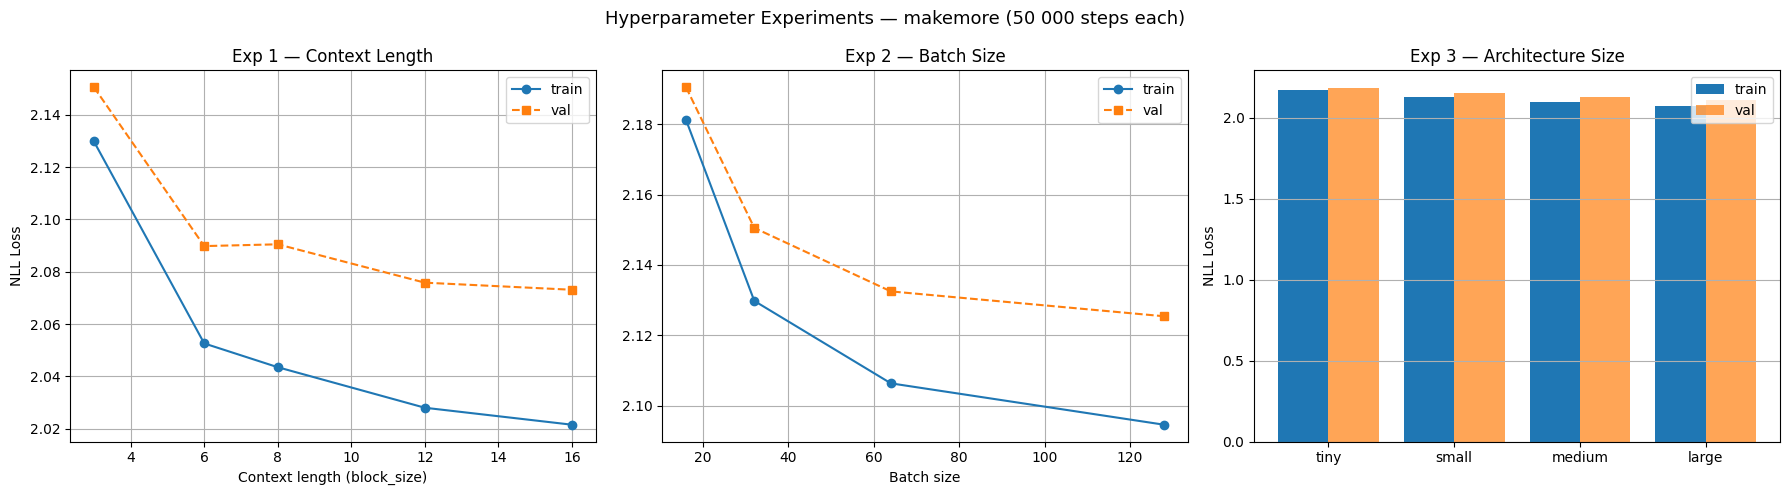


--- Context Length ---
  block_size      train        val
           3     2.1298     2.1505
           6     2.0526     2.0898
           8     2.0435     2.0905
          12     2.0280     2.0758
          16     2.0216     2.0731

--- Batch Size ---
  batch_size      train        val
          16     2.1812     2.1905
          32     2.1298     2.1505
          64     2.1064     2.1325
         128     2.0946     2.1254

--- Architecture ---
     label  n_embd  n_hidden      train        val
      tiny       8       100     2.1724     2.1824
     small      10       200     2.1298     2.1505
    medium      16       300     2.0945     2.1277
     large      24       400     2.0734     2.1106


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Context length
ax = axes[0]
bs = [r['block_size'] for r in ctx_results]
ax.plot(bs, [r['train'] for r in ctx_results], 'o-', label='train')
ax.plot(bs, [r['val']   for r in ctx_results], 's--', label='val')
ax.set_xlabel('Context length (block_size)')
ax.set_ylabel('NLL Loss')
ax.set_title('Exp 1 — Context Length')
ax.legend(); ax.grid(True)

# Batch size
ax = axes[1]
bs2 = [r['batch_size'] for r in batch_results]
ax.plot(bs2, [r['train'] for r in batch_results], 'o-', label='train')
ax.plot(bs2, [r['val']   for r in batch_results], 's--', label='val')
ax.set_xlabel('Batch size')
ax.set_title('Exp 2 — Batch Size')
ax.legend(); ax.grid(True)

# Architecture
ax = axes[2]
labels = [r['label'] for r in arch_results]
x = range(len(labels))
ax.bar([i-0.2 for i in x], [r['train'] for r in arch_results], 0.4, label='train')
ax.bar([i+0.2 for i in x], [r['val']   for r in arch_results], 0.4, label='val', alpha=0.7)
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('NLL Loss'); ax.set_title('Exp 3 — Architecture Size')
ax.legend(); ax.grid(True, axis='y')

plt.suptitle('Hyperparameter Experiments — makemore (50 000 steps each)', fontsize=13)
plt.tight_layout()
img_path = 'checkpoints/hyperparameter_summary.png'
plt.savefig(img_path, dpi=100, bbox_inches='tight')
plt.show()

# Log summary image to MLflow (arbitrary run — open a throwaway run)
with mlflow.start_run(run_name='hyperparameter-summary', tags={'experiment': 'summary'}):
    mlflow.log_artifact(img_path)

# Print numeric tables
print('\n--- Context Length ---')
print(f'{"block_size":>12} {"train":>10} {"val":>10}')
for r in ctx_results:
    print(f'{r["block_size"]:>12} {r["train"]:>10.4f} {r["val"]:>10.4f}')

print('\n--- Batch Size ---')
print(f'{"batch_size":>12} {"train":>10} {"val":>10}')
for r in batch_results:
    print(f'{r["batch_size"]:>12} {r["train"]:>10.4f} {r["val"]:>10.4f}')

print('\n--- Architecture ---')
print(f'{"label":>10} {"n_embd":>7} {"n_hidden":>9} {"train":>10} {"val":>10}')
for r in arch_results:
    print(f'{r["label"]:>10} {r["n_embd"]:>7} {r["n_hidden"]:>9} {r["train"]:>10.4f} {r["val"]:>10.4f}')
